In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [154]:
thruput_bug = pd.read_csv('/home/dhu/github/playground/languages/c++/prep/surface-bug.csv')
thruput = pd.read_csv('/home/dhu/github/playground/languages/c++/prep/surface.csv')
thruput_dense = pd.read_csv('/home/dhu/github/playground/languages/c++/prep/surface-dense.csv')

In [122]:
thruput

,type,queueSize,generated,collected,elapsedInMicros,retryOnFull
0,MutexBased,256,100,100,142,1
1,MutexBased,256,100,100,318,0
2,MutexBased,512,100,100,162,1
3,MutexBased,512,100,100,350,0
4,MutexBased,1024,100,100,263,1
...,...,...,...,...,...,...
907,LockFreeBased,2048,1500000,1298349,7165,0
908,LockFreeBased,4096,1500000,1500000,9807,1
909,LockFreeBased,4096,1500000,1437279,8096,0
910,LockFreeBased,8192,1500000,1500000,9204,1


In [123]:
retry_bug = thruput_bug[(thruput_bug['retryOnFull'] == 1)]
mu_retry = thruput[(thruput['type'] == 'MutexBased') & (thruput['retryOnFull'] == 1)]
lf_retry = thruput[(thruput['type'] == 'LockFreeBased') & (thruput['retryOnFull'] == 1)]

In [124]:
retry_bug[retry_bug['generated'] != retry_bug['collected']]

,type,queueSize,generated,collected,elapsedInMicros,retryOnFull
162,MutexBased,2048,5000,4608,894,1


In [125]:
mu_retry[mu_retry['generated'] != mu_retry['collected']]

,type,queueSize,generated,collected,elapsedInMicros,retryOnFull


In [126]:
lf_retry[lf_retry['generated'] != lf_retry['collected']]

,type,queueSize,generated,collected,elapsedInMicros,retryOnFull


In [179]:
def plot_surface(mu_data, lf_data, size=(12, 6), same_scale=True):
    global_elapsed_max = np.maximum(mu_data['elapsedInMicros'].max(), lf_data['elapsedInMicros'].max())
    global_elapsed_min = np.minimum(mu_data['elapsedInMicros'].min(), lf_data['elapsedInMicros'].min())
    
    fig, axes = plt.subplots(1, 2, figsize=size)
    for i, data, name in zip([0, 1], [mu_data, lf_data], ['mutex', 'lockfree']):
        if same_scale:
            sc = axes[i].scatter(
                data['queueSize'], data['generated'], 
                vmin=global_elapsed_min, vmax=global_elapsed_max,
                c=data['elapsedInMicros'], cmap='plasma')
        else:
            sc = axes[i].scatter(
                data['queueSize'], data['generated'],
                c=data['elapsedInMicros'], cmap='plasma')
        fig.colorbar(sc, ax=axes[i], label='elapsed(us)')
        axes[i].set_xlabel('queue capacity')
        axes[i].set_ylabel('generated#')
        axes[i].set_title(name)

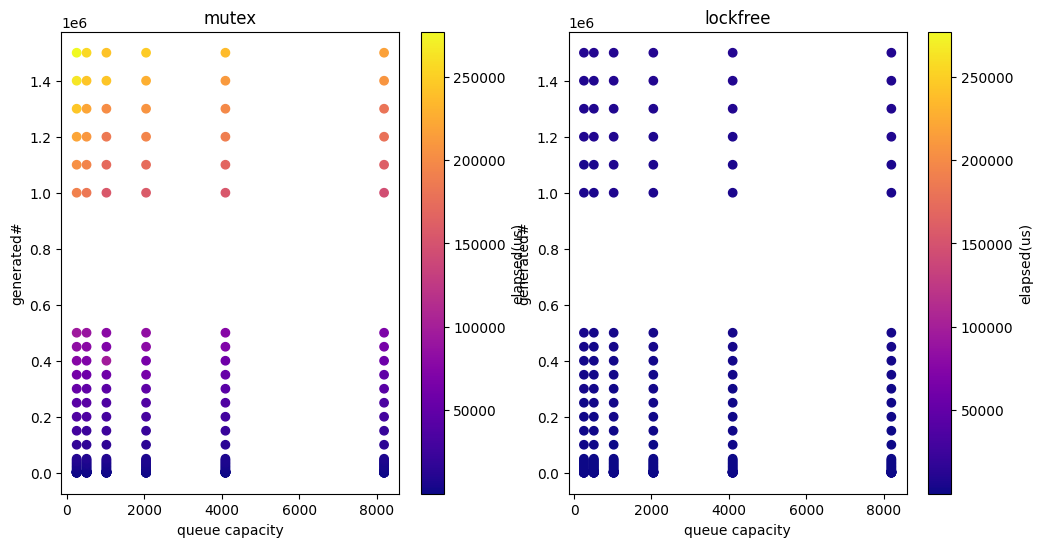

In [128]:
plot_surface(mu_retry, lf_retry)

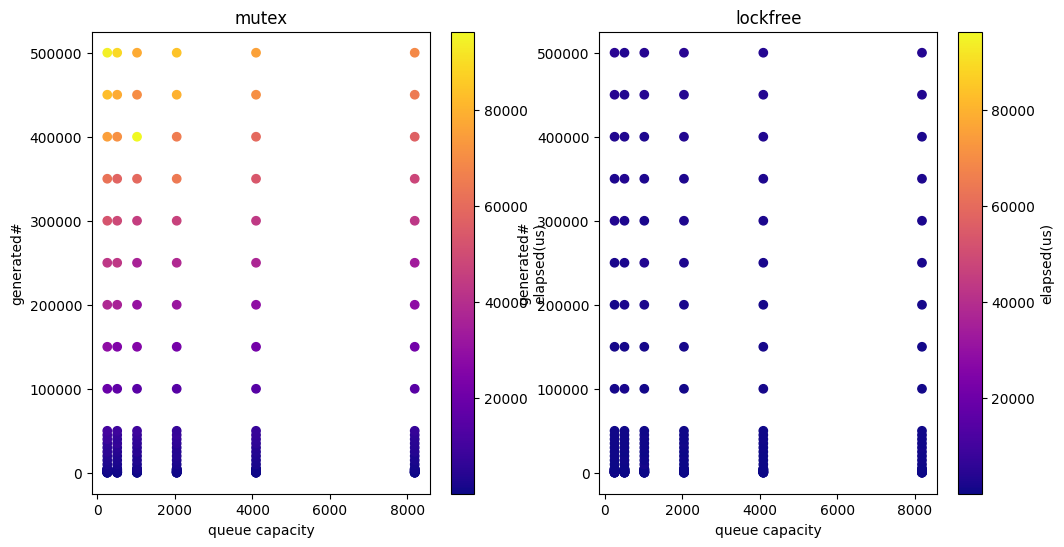

In [129]:
# plot data with < 1M generated data points
mu_retry_less_1m = mu_retry[mu_retry['generated'] < 1000000]
lf_retry_less_1m = lf_retry[lf_retry['generated'] < 1000000]
plot_surface(mu_retry_less_1m, lf_retry_less_1m)

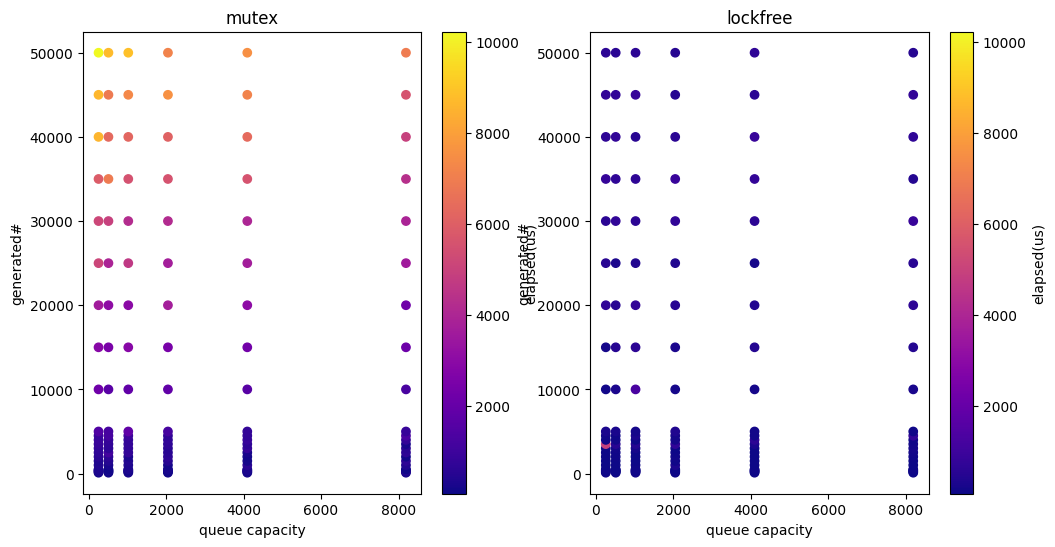

In [130]:
# plot data with < 100k generated data points
mu_retry_less_100k = mu_retry[mu_retry['generated'] < 100000]
lf_retry_less_100k = lf_retry[lf_retry['generated'] < 100000]
plot_surface(mu_retry_less_100k, lf_retry_less_100k)

In [131]:
mu_retry_keyed = mu_retry.set_index(['queueSize', 'generated'])
mu_retry_keyed.head()

,,type,collected,elapsedInMicros,retryOnFull
queueSize,generated,,,,
256,100,MutexBased,100,142,1
512,100,MutexBased,100,162,1
1024,100,MutexBased,100,263,1
2048,100,MutexBased,100,206,1
4096,100,MutexBased,100,225,1


In [132]:
lf_retry_keyed = lf_retry.set_index(['queueSize', 'generated'])
lf_retry_keyed.head()

,,type,collected,elapsedInMicros,retryOnFull
queueSize,generated,,,,
256,100,LockFreeBased,100,258,1
512,100,LockFreeBased,100,112,1
1024,100,LockFreeBased,100,157,1
2048,100,LockFreeBased,100,111,1
4096,100,LockFreeBased,100,155,1


In [133]:
retry_elapsed = pd.concat([mu_retry_keyed['elapsedInMicros'], lf_retry_keyed['elapsedInMicros']], axis=1, keys=['mutex', 'lockfree'])
retry_elapsed['ratio'] = retry_elapsed['mutex'] / retry_elapsed['lockfree']
retry_elapsed.reset_index(inplace=True)
retry_elapsed

,queueSize,generated,mutex,lockfree,ratio
0,256,100,142,258,0.550388
1,512,100,162,112,1.446429
2,1024,100,263,157,1.675159
3,2048,100,206,111,1.855856
4,4096,100,225,155,1.451613
...,...,...,...,...,...
223,512,1500000,255975,9932,25.772755
224,1024,1500000,241853,10013,24.153900
225,2048,1500000,247337,10793,22.916427
226,4096,1500000,236671,9807,24.132864


In [134]:
def make_ratio_df(mu, lf):
    mu_keyed = mu.set_index(['queueSize', 'generated'])
    lf_keyed = lf.set_index(['queueSize', 'generated'])
    comp = pd.concat([mu_keyed['elapsedInMicros'], lf_keyed['elapsedInMicros']], axis=1, keys=['mutex', 'lockfree'])
    comp['ratio'] = comp['mutex'] / comp['lockfree']
    comp.reset_index(inplace=True)
    return comp

In [135]:
make_ratio_df(mu_retry, lf_retry)

,queueSize,generated,mutex,lockfree,ratio
0,256,100,142,258,0.550388
1,512,100,162,112,1.446429
2,1024,100,263,157,1.675159
3,2048,100,206,111,1.855856
4,4096,100,225,155,1.451613
...,...,...,...,...,...
223,512,1500000,255975,9932,25.772755
224,1024,1500000,241853,10013,24.153900
225,2048,1500000,247337,10793,22.916427
226,4096,1500000,236671,9807,24.132864


In [136]:
def plot_ratio(data, size):
    fig, ax = plt.subplots(figsize=size) # same as 1, 1
    sc = ax.scatter(data['queueSize'], data['generated'], c=data['ratio'], cmap='plasma')
    fig.colorbar(sc, ax=ax, label='mutex / lockfree')
    ax.set_xlabel('queue size')
    ax.set_ylabel('generated#')

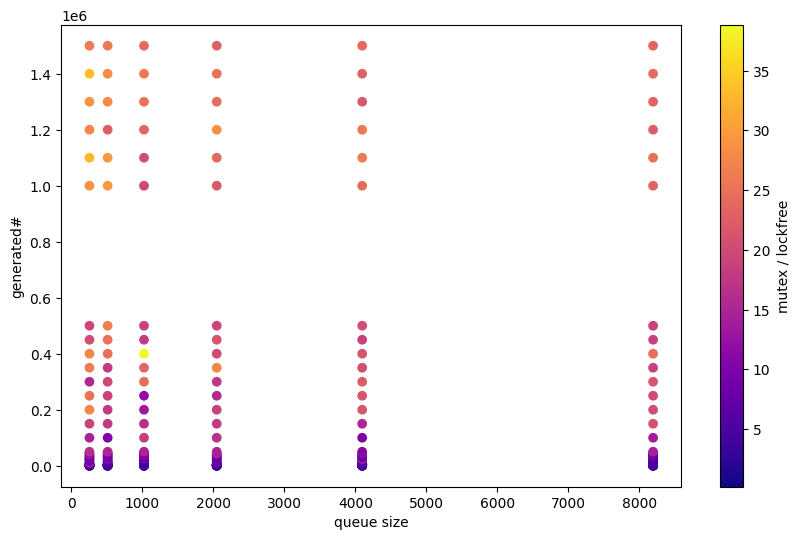

In [137]:
plot_ratio(retry_elapsed, (10, 6))

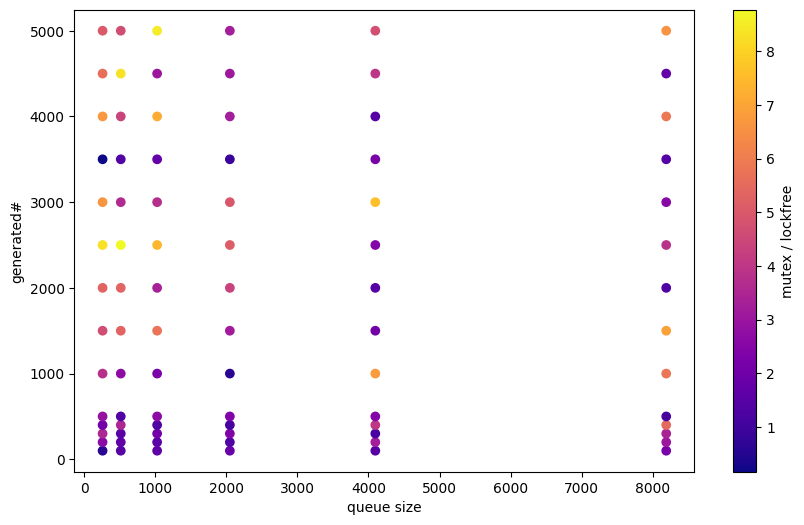

In [138]:
plot_ratio(retry_elapsed[retry_elapsed['generated'] < 10000], (10, 6))

In [155]:
mu_dense = thruput_dense[(thruput_dense['type'] == 'MutexBased') & (thruput_dense['retryOnFull'] == 1)]
lf_dense = thruput_dense[(thruput_dense['type'] == 'LockFreeBased') & (thruput_dense['retryOnFull'] == 1)]

In [157]:
dense_comp = make_ratio_df(mu_dense, lf_dense)
dense_comp

,queueSize,generated,mutex,lockfree,ratio
0,100,1000,440,311,1.414791
1,200,1000,253,218,1.160550
2,300,1000,361,319,1.131661
3,400,1000,452,252,1.793651
4,500,1000,351,126,2.785714
...,...,...,...,...,...
3995,1600,200000,33207,1968,16.873476
3996,1700,200000,29234,1537,19.020169
3997,1800,200000,36851,1586,23.235183
3998,1900,200000,31803,2001,15.893553


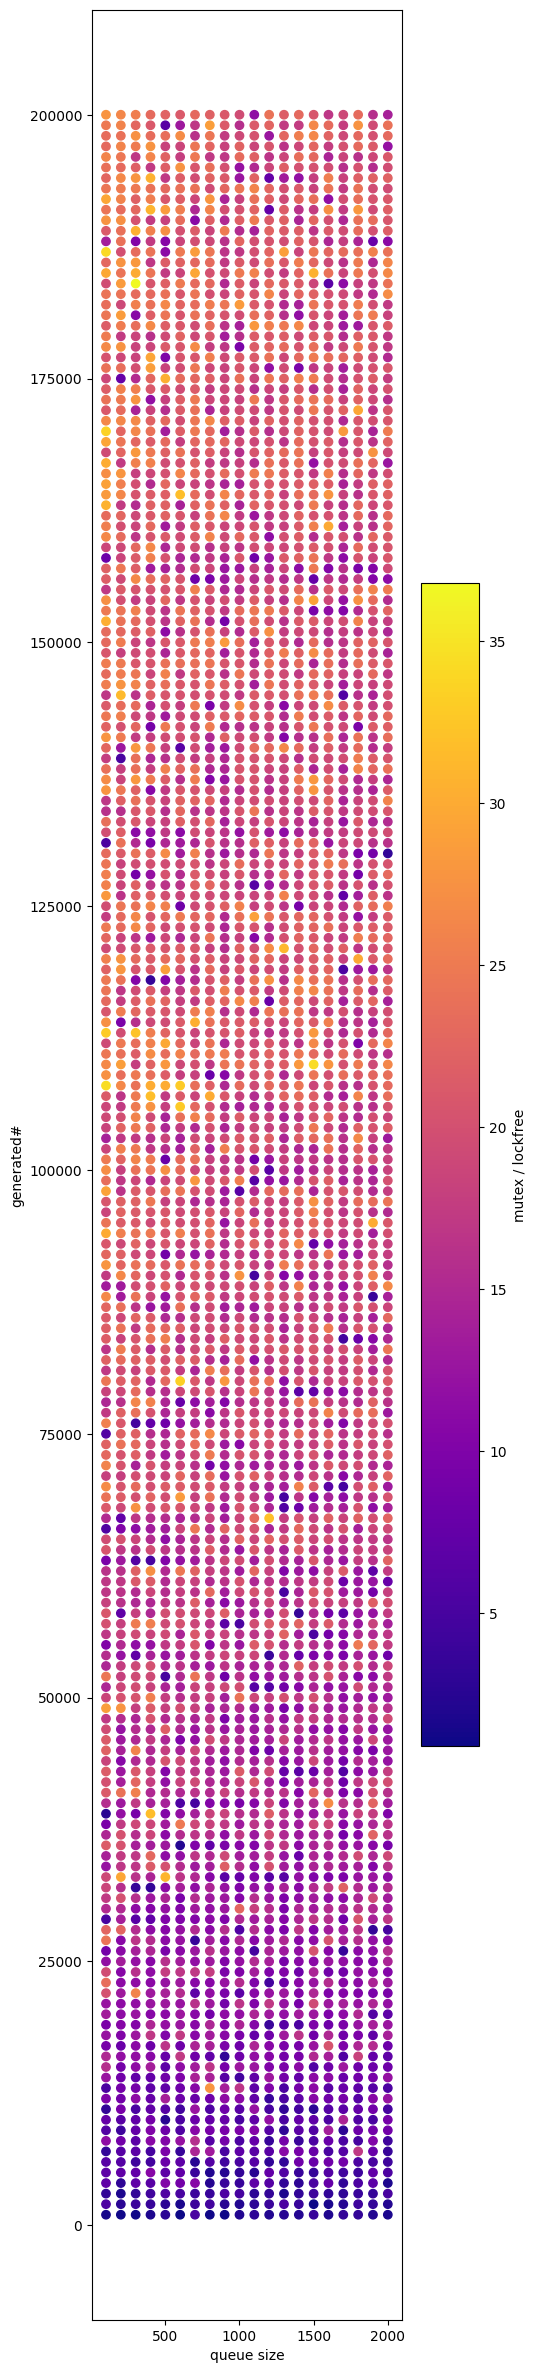

In [168]:
plot_ratio(dense_comp, (5, 30))

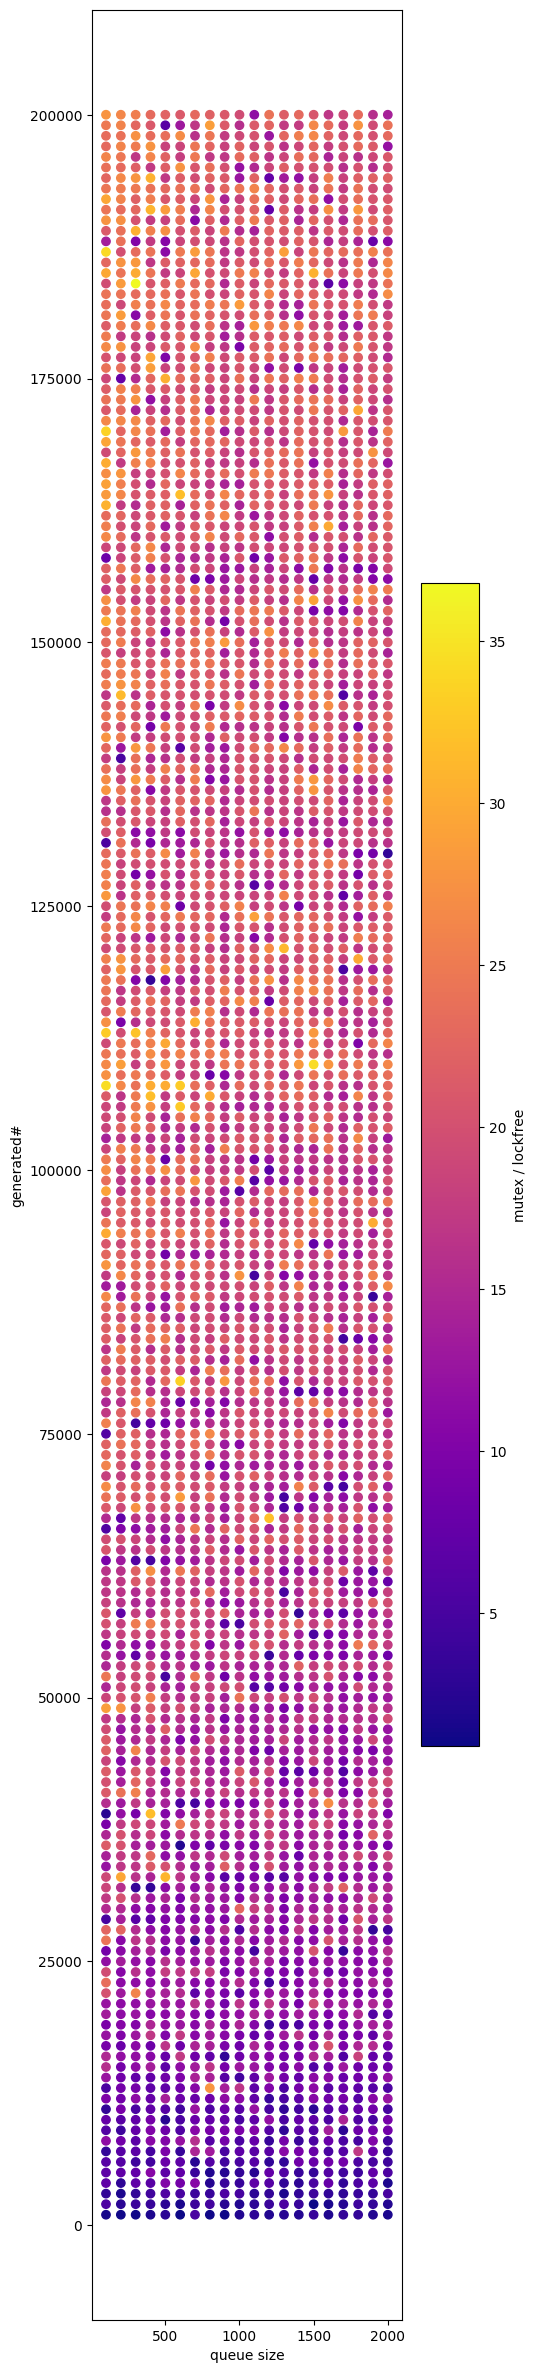

In [167]:
plot_ratio(dense_comp[dense_comp['generated'] > 100], (5, 30))

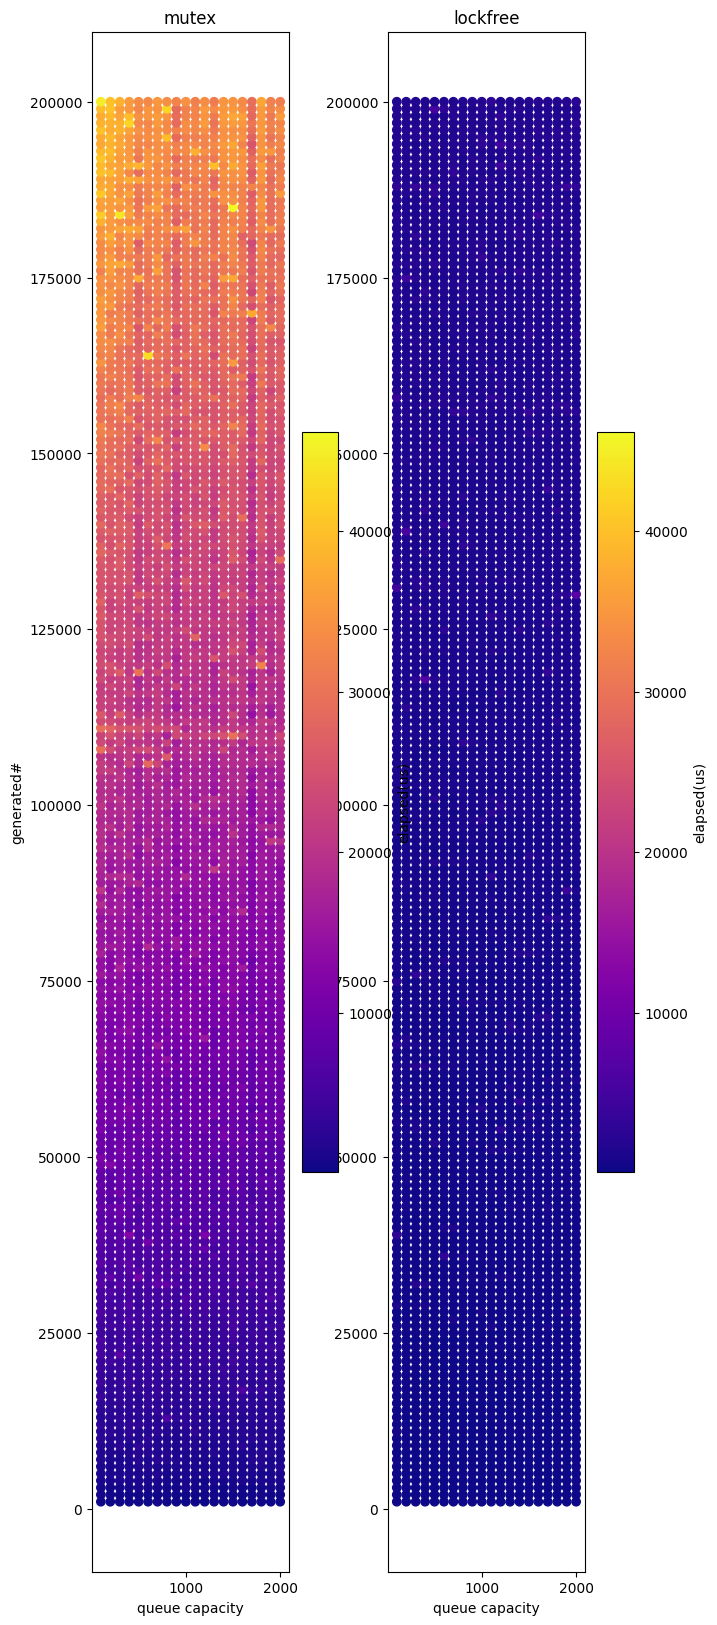

In [174]:
plot_surface(mu_dense, lf_dense, (7, 20))

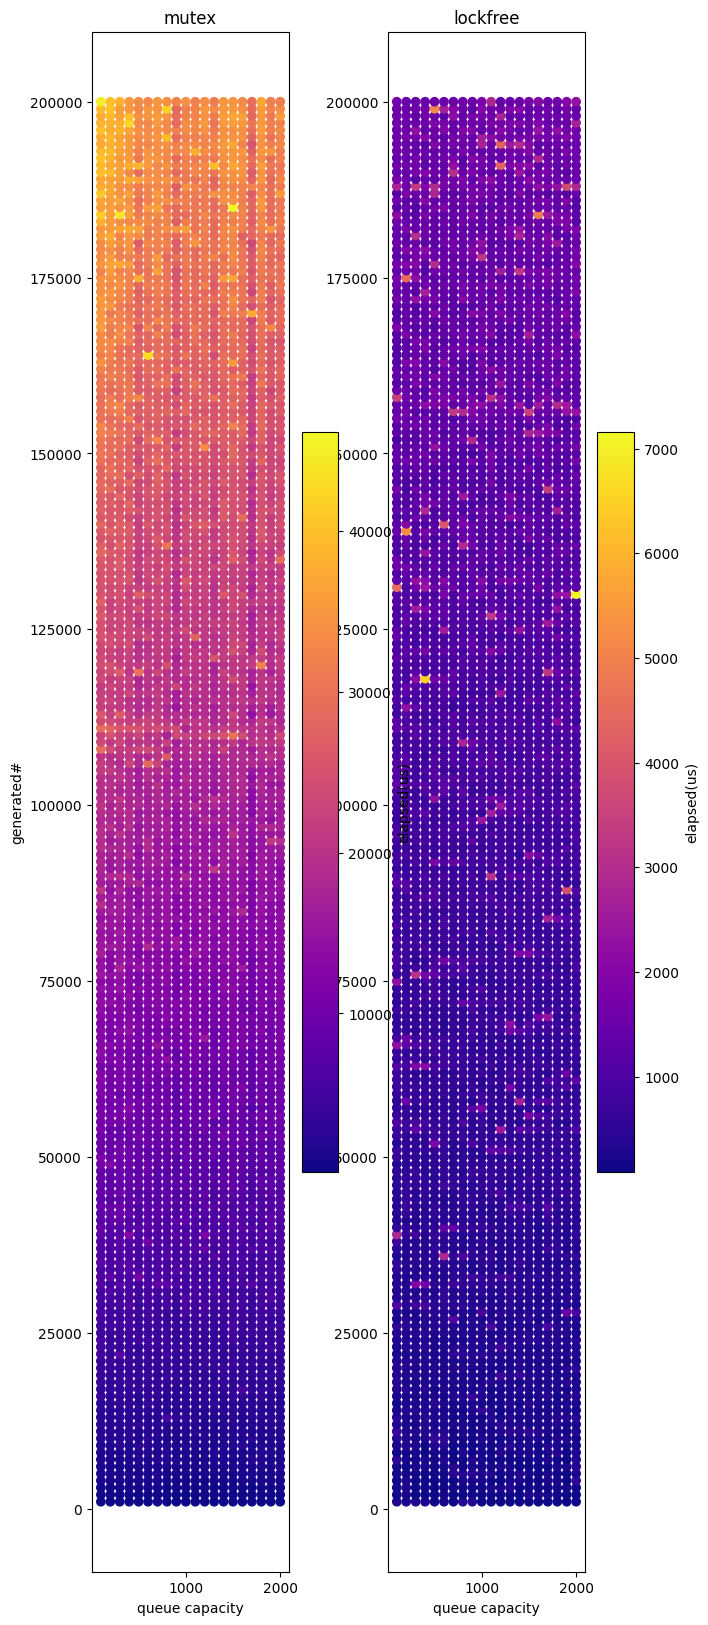

In [180]:
plot_surface(mu_dense, lf_dense, (7, 20), same_scale=False)